In [ ]:
# Install required packages
!pip install pandas matplotlib seaborn nltk wordcloud

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from nltk.util import ngrams

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load dataset
file_path = '/content/drive/MyDrive/MentalBERT_Project/data/depressed_mood_10K_v1.csv'
df = pd.read_csv(file_path)

# Inspect data
print("Dataset Info:")
print(df.info())
print("\nSample Rows:")
print(df.head())
print("\nSymptom Counts:")
print(df['symptom'].value_counts())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10000 non-null  object 
 1   created_at    10000 non-null  object 
 2   title         10000 non-null  object 
 3   selftext      10000 non-null  object 
 4   author        10000 non-null  object 
 5   score         10000 non-null  int64  
 6   upvote_ratio  10000 non-null  float64
 7   num_comments  10000 non-null  int64  
 8   over_18       10000 non-null  bool   
 9   symptom       10000 non-null  object 
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 713.0+ KB
None

Sample Rows:
        id            created_at  \
0  1gt8h3t  2024-11-17T07:36:39Z   
1  1bmmt32  2024-03-24T15:02:17Z   
2  1d97d4b  2024-06-06T02:12:28Z   
3  1bd560b  2024-03-12T18:51:51Z   
4  1hdo2y4  2024-12-13T22:26:26Z   

                                               title 

In [ ]:
# Combine title and selftext
df['text'] = df['title'].fillna('') + ' ' + df['selftext'].fillna('')

# Clean text: lowercase, remove punctuation, stopwords
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation, numbers
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]  # Remove stopwords, short words
    return ' '.join(tokens)
df['clean_text'] = df['text'].apply(clean_text)

# Word count
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
print("\nWord Count Stats:")
print(df['word_count'].describe())


Word Count Stats:
count    10000.000000
mean        88.948700
std         49.684611
min         16.000000
25%         50.000000
50%         78.000000
75%        118.000000
max        351.000000
Name: word_count, dtype: float64


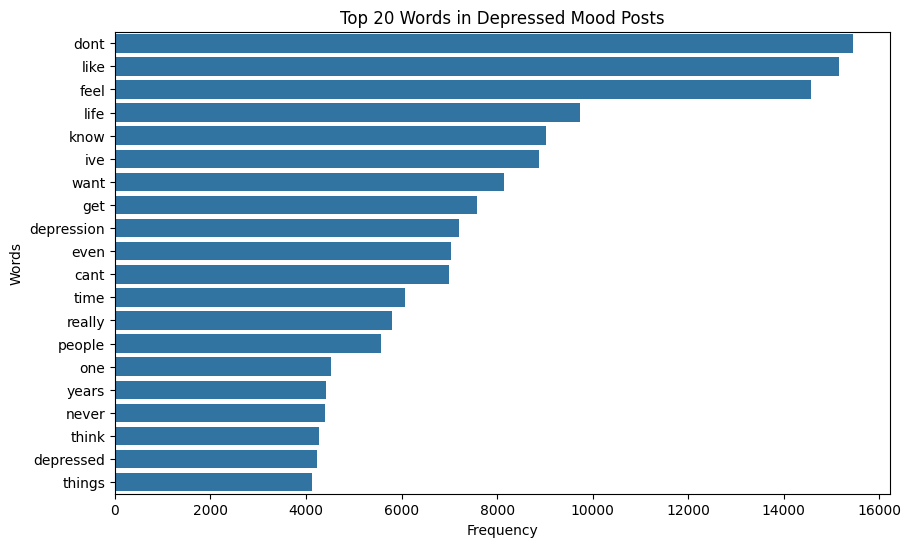

In [ ]:
# Word frequencies
all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words)

top_words = word_freq.most_common(20)
words, counts = zip(*top_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words))
plt.title('Top 20 Words in Depressed Mood Posts')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()


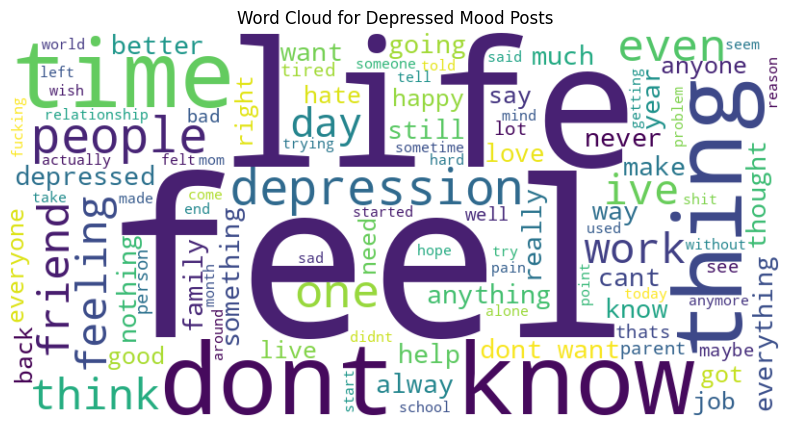

In [ ]:
# Word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, random_state=42).generate(' '.join(all_words))


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Depressed Mood Posts')
plt.show()

In [ ]:
# get ngrams
def get_ngrams(text, n):
    tokens = text.split()
    return list(ngrams(tokens, n))

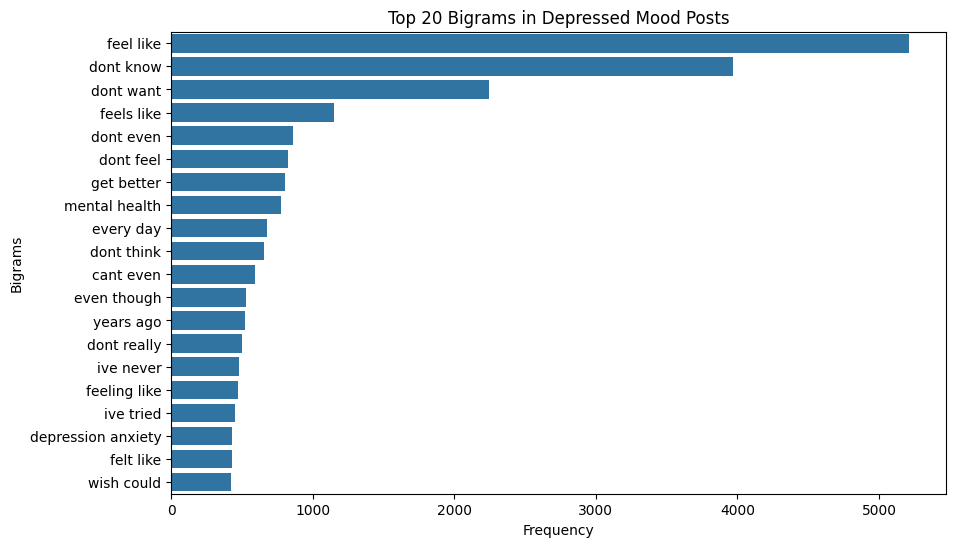

In [ ]:
# Bigrams

bigrams = [bigram for text in df['clean_text'] for bigram in get_ngrams(text, 2)]
bigram_freq = Counter(bigrams)

# Bigram bar chart
top_bigrams = bigram_freq.most_common(20)
bigrams, counts = zip(*[( ' '.join(b), c) for b, c in top_bigrams])
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(bigrams))
plt.title('Top 20 Bigrams in Depressed Mood Posts')
plt.xlabel('Frequency')
plt.ylabel('Bigrams')
plt.show()

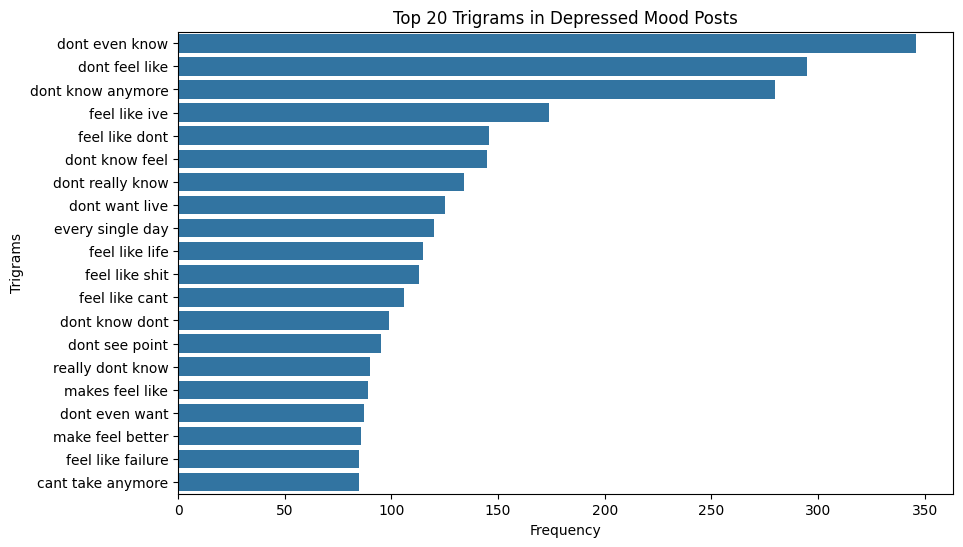

In [ ]:
# Trigrams

trigrams = [trigram for text in df['clean_text'] for trigram in get_ngrams(text, 3)]
trigram_freq = Counter(trigrams)

# Trigram bar chart
top_trigrams = trigram_freq.most_common(20)
trigrams, counts = zip(*[( ' '.join(b), c) for b, c in top_trigrams])
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(trigrams))
plt.title('Top 20 Trigrams in Depressed Mood Posts')
plt.xlabel('Frequency')
plt.ylabel('Trigrams')
plt.show()


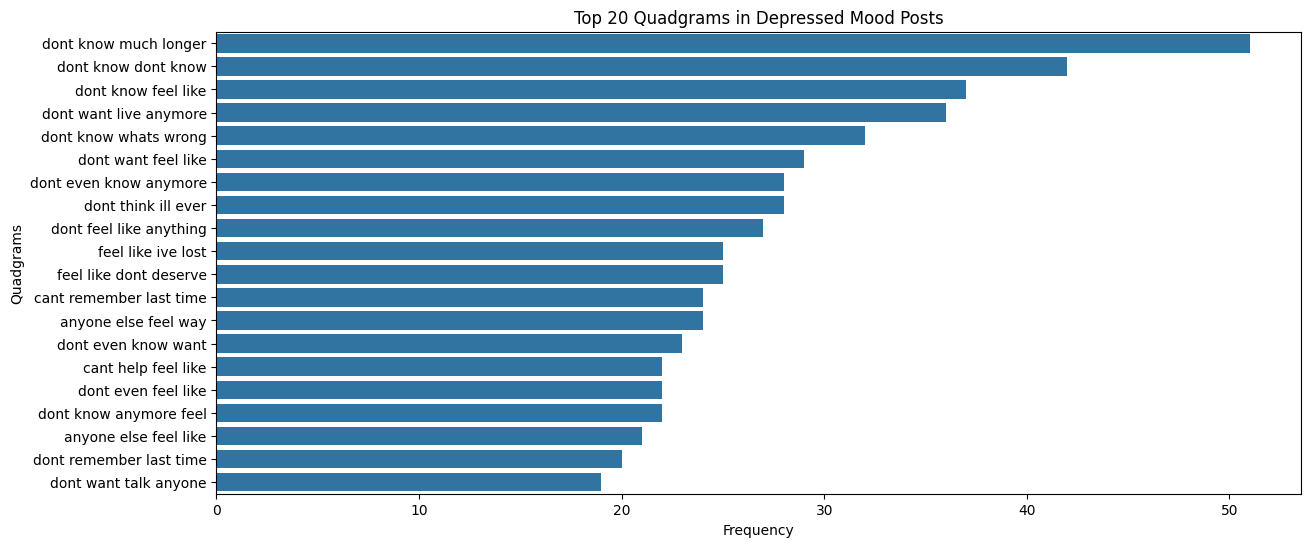

In [ ]:
# Quadgrams
quadgrams = [quadgram for text in df['clean_text'] for quadgram in get_ngrams(text, 4)]
quadgram_freq = Counter(quadgrams)

# Quadgram bar chart
top_quadgrams = quadgram_freq.most_common(20)
quadgrams, counts = zip(*[(' '.join(q), c) for q, c in top_quadgrams])
plt.figure(figsize=(14, 6))
sns.barplot(x=list(counts), y=list(quadgrams))
plt.title('Top 20 Quadgrams in Depressed Mood Posts')
plt.xlabel('Frequency')
plt.ylabel('Quadgrams')
plt.show()

/tmp/ipython-input-28-4190545925.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = pd.to_datetime(df['created_at']).dt.to_period('M')  # CHANGED: Removed unit='s' to parse ISO 8601 format


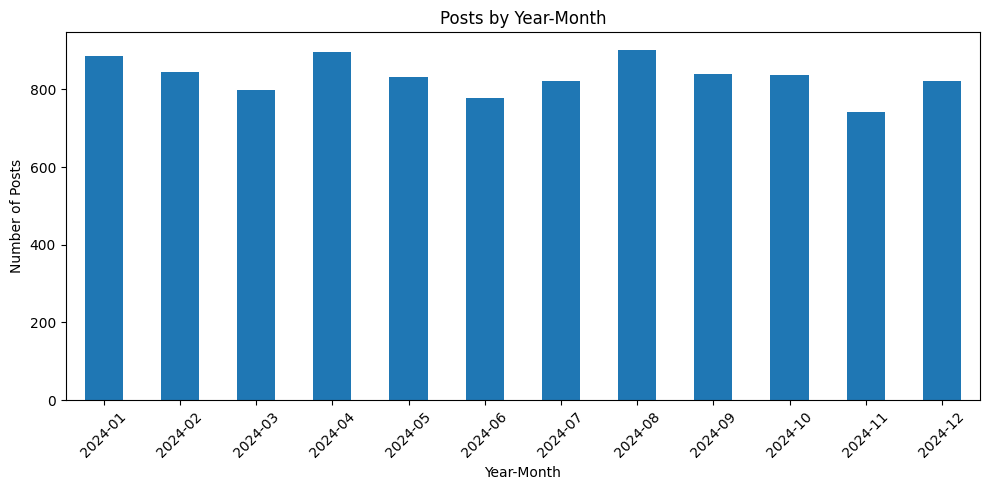

In [ ]:

# Posts by year-month
df['year_month'] = pd.to_datetime(df['created_at']).dt.to_period('M')  # CHANGED: Removed unit='s' to parse ISO 8601 format
plt.figure(figsize=(10, 5))
df['year_month'].value_counts().sort_index().plot(kind='bar')
plt.title('Posts by Year-Month')
plt.xlabel('Year-Month')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

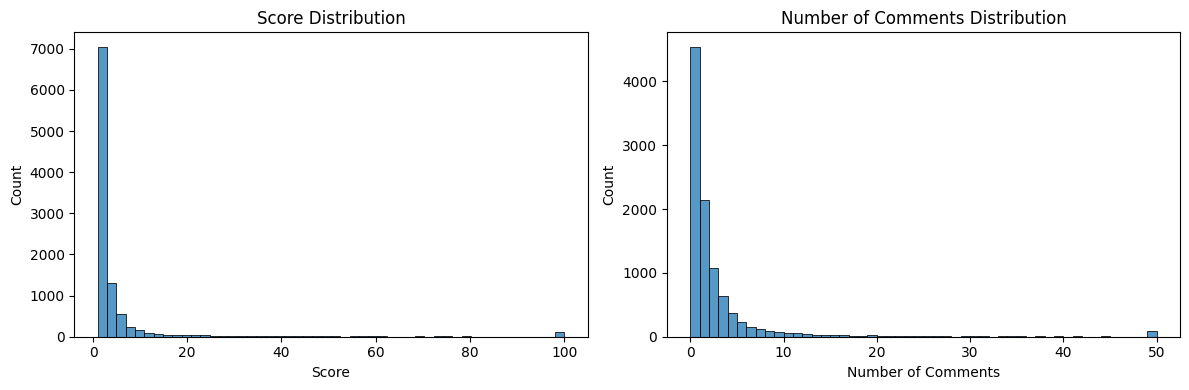

In [ ]:
# Engagement distributions
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['score'].clip(upper=100), bins=50)
plt.title('Score Distribution')
plt.xlabel('Score')
plt.subplot(1, 2, 2)
sns.histplot(df['num_comments'].clip(upper=50), bins=50)
plt.title('Number of Comments Distribution')
plt.xlabel('Number of Comments')
plt.tight_layout()
plt.show()

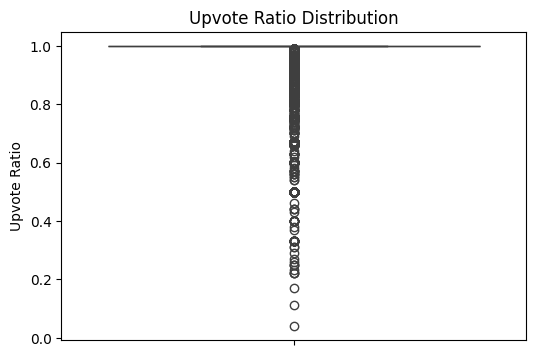

In [ ]:
# Upvote ratio boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['upvote_ratio'])
plt.title('Upvote Ratio Distribution')
plt.ylabel('Upvote Ratio')
plt.show()

In [ ]:
# Sentiment analysis
sid = SentimentIntensityAnalyzer()
df['sentiment'] = df['clean_text'].apply(lambda x: sid.polarity_scores(x)['compound'])
print("\nSentiment Stats:")
print(df['sentiment'].describe())



Sentiment Stats:
count    10000.000000
mean        -0.336338
std          0.752102
min         -0.998200
25%         -0.950200
50%         -0.779050
75%          0.459000
max          0.998100
Name: sentiment, dtype: float64


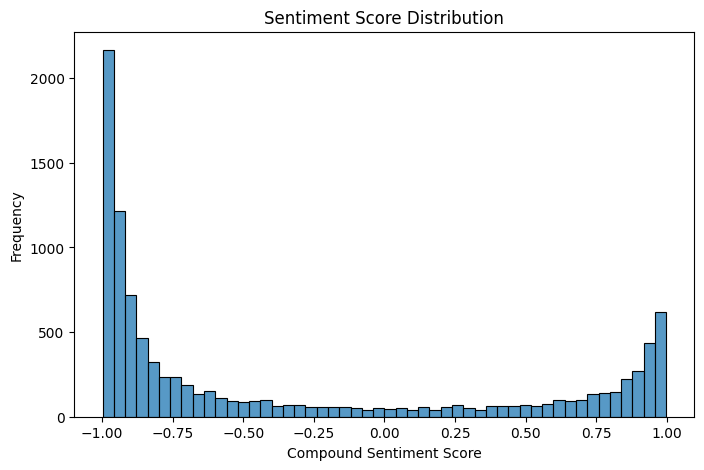

In [ ]:
# Sentiment distribution

plt.figure(figsize=(8, 5))
sns.histplot(df['sentiment'], bins=50)
plt.title('Sentiment Score Distribution')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Frequency')
plt.show()


In [ ]:
for col in df.columns:
    print(f"{col}: {df.iloc[0][col]}")

id: 1gt8h3t
created_at: 2024-11-17T07:36:39Z
title: I survived an attempt and need advice on how to prevent a future one
selftext: Hi everyone, I’m just looking for some advice on how to prevent any future attempts. I’m a 23 year old woman, live alone in an apartment, and have many different things in my apartment that can be used for self harm. 

I have severe C-PTSD and depression. I only narrowly survived my last attempt and don’t know if I’ll try again. I spend most of my time crying and anxious unless I’m asleep.

How can I best prevent any future attempts and what should I do if I do again? I don’t think that I’m able to understand mortality anymore and have a high probability of being successful. I also have siblings and parents who would be completely heartbroken if I passed and I don’t want to ruin their lives, I just can’t control myself and am in a lot of pain.
author: Yungwhippersnappa
score: 2
upvote_ratio: 1.0
num_comments: 8
over_18: False
symptom: depressed_mood
text: I

In [ ]:
# POS tagging: adjectives
def get_adjectives(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    return [word for word, pos in tagged if pos.startswith('JJ')]
adjectives = [adj for text in df['clean_text'] for adj in get_adjectives(text)]
adj_freq = Counter(adjectives)
print("\nTop 10 Adjectives:", adj_freq.most_common(10))


Top 10 Adjectives: [('ive', 7302), ('cant', 3910), ('dont', 3899), ('good', 3019), ('much', 2869), ('bad', 2671), ('happy', 2602), ('last', 2054), ('hard', 1929), ('sad', 1849)]
